In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")

In [350]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                
                fig,ax = plt.subplots(figsize = (8,4))
            
                sns.swarmplot(x=cat_name, y =column, data= param_df, palette = palette, order = order, alpha = 0.7, size = 4)
                sns.boxplot(x=cat_name, y =column, data= param_df, palette = palette, order = order, boxprops=dict(alpha=0.5), width = 0.5)
                sns.despine()
                plt.title(column, pad = 20)
                plt.xticks(rotation = 90)
                plt.savefig(f'output_figures/{name}_{column}.png',dpi = 300, bbox_inches = 'tight')
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# epnys analysis

In [351]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

include_gal = True

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)

cat = df.Behaviour_6hFD.unique()

if include_gal:
       gal = df[(df.Gal_positive == 'yes') & (df.Behaviour_6hFD == 'Pre')]
       no_gal = df[(df.Gal_positive == 'no') & (df.Behaviour_6hFD == 'Pre')]
       ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[df.Behaviour_6hFD != 'Pre']])
       sample_num= int(no_gal.shape[0]/4)
       ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 62)]).reset_index(drop = True)

else:
       ephys = df[df.Gal_positive == 'Unknown']
  
# ephys.loc[ephys.Behaviour_6hFD.isin([ 'npy_100_paired']),'Behaviour_6hFD'] = 'npy_100'
     
# ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv('sampled_ephys_data.csv')

In [352]:
behav = pd.read_csv('ephys_behav.csv')
ephys_behav = pd.merge(ephys, behav, on  = 'ID_mouse')
ephys_behav.columns = [col.replace('(', '_').replace(')', '_') for col in ephys_behav.columns]
ephys_behav.columns = [col.replace(' ', '_').replace('-', '_') for col in ephys_behav.columns]

In [353]:
ephys_behav.columns

Index(['experiment_day', 'sex', 'Gal_positive', 'state', 'estrous_stage',
       'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm_pF_', 'Adaptive',
       'I_zero', 'I_zero_reclassified', '60mV', 'Firing_freq__Hz__I0',
       'Instant_freq__Hz_', 'isi__ms_', 'cat_categ', 'CaT', 'Ih',
       'Ih_at__120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak',
       'area_mV_ms_', 'rheobase_at__60mV__pA_', 'AHP__mV_', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude_pA_',
       'sPSCs_Rise_time', 'sPSCs__decay_', 'AC_I0', 'AC__60', 'Comments',
       'estrous_confirmation', 'pup_intro', 'contact', 'attack',
       'contact_latency', 'attack_latency', 'attack_since_contact'],
      dtype='object')

In [354]:
percent_columns = ['Ih_at__120mV', 'CaT', 'Adaptive', 'Firing_freq__Hz__I0'] 
percentages_df = pd.DataFrame(index=ephys_behav['ID_mouse'].unique())

for column in percent_columns:
    percentages = ephys_behav.groupby('ID_mouse')[column].apply(lambda x: (x == 0).sum() / len(x) * 100)
    percentages_df[column + '_percent_nonzero'] = percentages

silent_percentages = ephys_behav.groupby('ID_mouse')['I_zero_reclassified'].apply(lambda x: (x == 'silent').sum() / len(x) * 100).reset_index(name='I_zero_reclassified' + '_percent_silent')
percentages_df = percentages_df.reset_index()
percentages_df.rename(columns={'index': 'ID_mouse'}, inplace=True)
percentages_df = pd.merge(percentages_df, silent_percentages, on='ID_mouse', how='outer')

percentages_df = pd.merge(percentages_df, behav, on = 'ID_mouse')




In [355]:
for y in percentages_df.columns[1:-6]:
    if y != 'attack_since_contact':  # Skip the contact_latency column
        formula = 'attack_since_contact ~ ' + y
        try:
            model = smf.ols(formula, data=percentages_df).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_since_contact', y = y, data = percentages_df)
           
        except Exception as e:
            continue

0.01944928104928148 sPSC_Amplitude_pA_ 0.31337716718782116


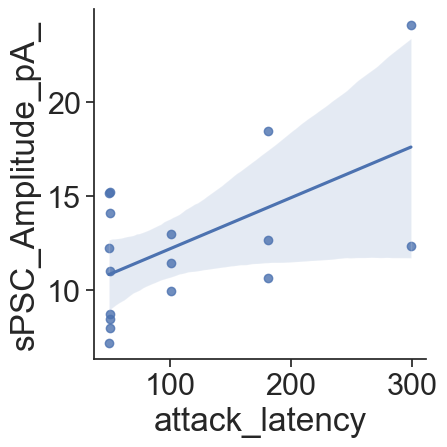

In [356]:
#ephys correlation with behaviour metric
for y in ephys_behav.columns[8:-8]:
    if y != 'contact_latency':  # Skip the contact_latency column
        formula = 'attack_latency ~ ' + y
        try:
            model = smf.ols(formula, data=ephys_behav).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_latency', y = y, data = ephys_behav)
                plt.show()
           
        except Exception as e:
            continue
    

In [357]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

## all properties

Cm(pF) ('Pre', 'Agg+') 0.2112995473337107
Cm(pF) ('Pre', 'Agg-') 0.5290508623404895
Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.005440878392174709
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.050500440681557957
Firing_freq_(Hz)_I0 ('Pre', 'npy1r_antag') 0.2573383694997692
Firing_freq_(Hz)_I0 ('Pre', 'npy2r_antag') 0.6559386848670401
Firing_freq_(Hz)_I0 ('Pre', 'npy_100') 0.02323222231920088
Firing_freq_(Hz)_I0 ('Pre', 'ZD7288') 0.00160254915119926
Firing_freq_(Hz)_I0 ('Pre', 'npykd') 0.41254486462380224
Firing_freq_(Hz)_I0 ('Agg+', 'Agg-') 0.00023960473006254693
Firing_freq_(Hz)_I0 ('Agg+', 'npy1r_antag') 0.009940398606776245
Firing_freq_(Hz)_I0 ('Agg+', 'npy2r_antag') 0.04749332080646246
Firing_freq_(Hz)_I0 ('Agg+', 'npy_100') 0.6059668047013369
Firing_freq_(Hz)_I0 ('Agg+', 'ZD7288') 0.08010008068681015
Firing_freq_(Hz)_I0 ('Agg+', 'npykd') 0.010676811283970683
Firing_freq_(Hz)_I0 ('Agg-', 'npy1r_antag') 0.7211105212310518
Firing_freq_(Hz)_I0 ('Agg-', 'npy2r_antag') 0.595301804358754
Firing_freq_(

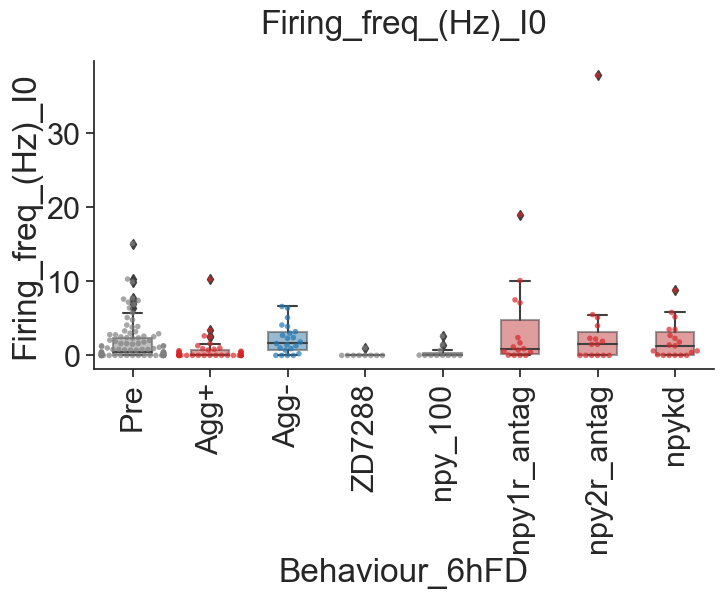

Instant_freq_(Hz) ('Pre', 'Agg+') 0.0037439876595372667
Instant_freq_(Hz) ('Pre', 'Agg-') 0.13791987695468466
Instant_freq_(Hz) ('Pre', 'npy1r_antag') 0.3387879475549421
Instant_freq_(Hz) ('Pre', 'npy2r_antag') 0.641518798665808
Instant_freq_(Hz) ('Pre', 'npy_100') 0.02294983030502359
Instant_freq_(Hz) ('Pre', 'ZD7288') 0.002066214299640664
Instant_freq_(Hz) ('Pre', 'npykd') 0.3928748109158061
Instant_freq_(Hz) ('Agg+', 'Agg-') 0.0005972637186570449
Instant_freq_(Hz) ('Agg+', 'npy1r_antag') 0.008821885664192244
Instant_freq_(Hz) ('Agg+', 'npy2r_antag') 0.0474498358894257
Instant_freq_(Hz) ('Agg+', 'npy_100') 0.5790081532112668
Instant_freq_(Hz) ('Agg+', 'ZD7288') 0.08805171553670911
Instant_freq_(Hz) ('Agg+', 'npykd') 0.01090289766664914
Instant_freq_(Hz) ('Agg-', 'npy1r_antag') 0.9381289063266207
Instant_freq_(Hz) ('Agg-', 'npy2r_antag') 0.7905716654506721
Instant_freq_(Hz) ('Agg-', 'npy_100') 0.008134465584857038
Instant_freq_(Hz) ('Agg-', 'ZD7288') 0.0018326276980825283
Instant_freq

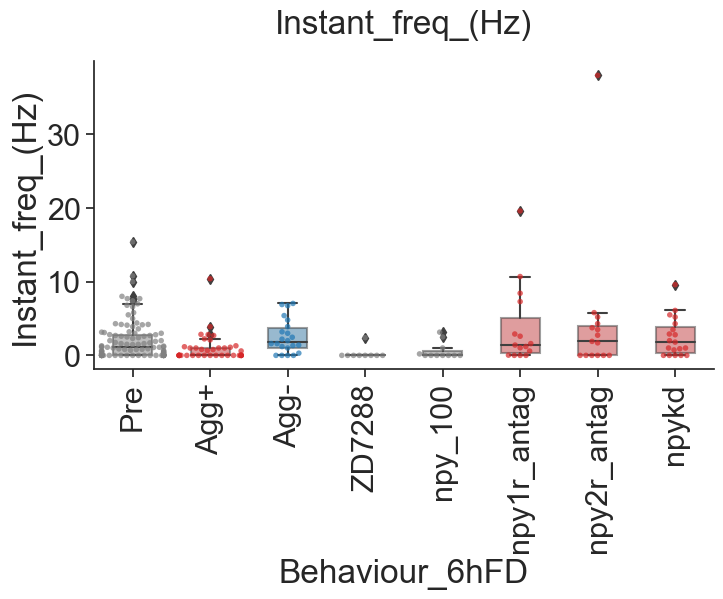

isi_(ms) ('Pre', 'Agg+') 0.6071887395501236
isi_(ms) ('Pre', 'Agg-') 0.054024744647440136
isi_(ms) ('Pre', 'npy1r_antag') 0.292912278038327
isi_(ms) ('Pre', 'npy2r_antag') 0.021073103643658463
isi_(ms) ('Pre', 'npy_100') 0.5721341949190052
isi_(ms) ('Pre', 'ZD7288') 0.9610389610389612
isi_(ms) ('Pre', 'npykd') 0.21863741859661434
isi_(ms) ('Agg+', 'Agg-') 0.00824611159729866
isi_(ms) ('Agg+', 'npy1r_antag') 0.22762429416533925
isi_(ms) ('Agg+', 'npy2r_antag') 0.004308943895944759
isi_(ms) ('Agg+', 'npy_100') 1.0
isi_(ms) ('Agg+', 'ZD7288') 0.7368421052631579
isi_(ms) ('Agg+', 'npykd') 0.09094854576136165
isi_(ms) ('Agg-', 'npy1r_antag') 0.6566808075579458
isi_(ms) ('Agg-', 'npy2r_antag') 0.2471599732119072
isi_(ms) ('Agg-', 'npy_100') 0.11784005468215993
isi_(ms) ('Agg-', 'ZD7288') 0.42105263157894735
isi_(ms) ('Agg-', 'npykd') 0.6899948772616324
isi_(ms) ('npy1r_antag', 'npy2r_antag') 0.3027893674905606
isi_(ms) ('npy1r_antag', 'npy_100') 0.5208791208791208
isi_(ms) ('npy1r_antag', 'Z

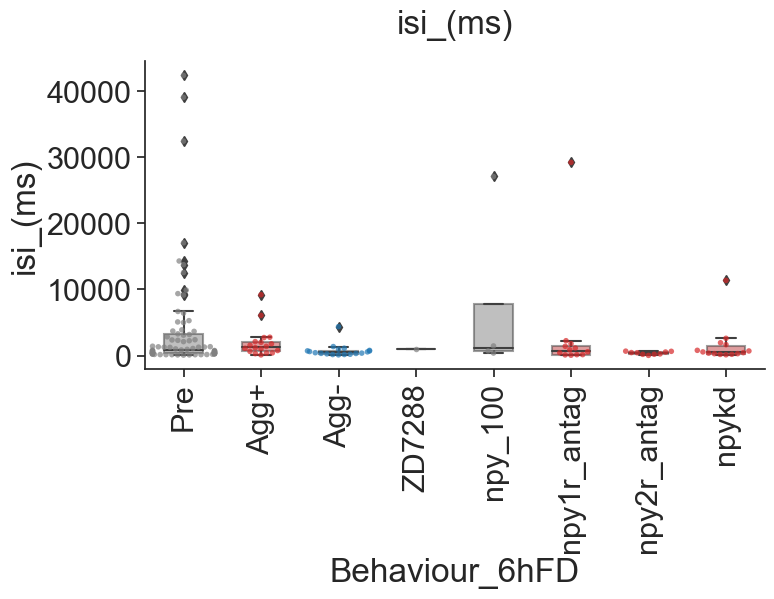

CaT ('Pre', 'Agg+') 0.8616819601003589
CaT ('Pre', 'Agg-') 0.3954543611558381
CaT ('Pre', 'npy1r_antag') 0.5461647859931317
CaT ('Pre', 'npy2r_antag') 0.5439000937747926
CaT ('Pre', 'npy_100') 0.9121941487321001
CaT ('Pre', 'ZD7288') 0.726065942091648
CaT ('Pre', 'npykd') 0.358546467067407
CaT ('Agg+', 'Agg-') 0.3516475723043333
CaT ('Agg+', 'npy1r_antag') 0.7568099810952852
CaT ('Agg+', 'npy2r_antag') 0.7247499060941998
CaT ('Agg+', 'npy_100') 0.9656338999381497
CaT ('Agg+', 'ZD7288') 0.8293818536260558
CaT ('Agg+', 'npykd') 0.43859505260713993
CaT ('Agg-', 'npy1r_antag') 0.16745288464179808
CaT ('Agg-', 'npy2r_antag') 0.23228925181341442
CaT ('Agg-', 'npy_100') 0.2823571409583424
CaT ('Agg-', 'ZD7288') 0.4969394928289175
CaT ('Agg-', 'npykd') 0.13214757065294017
CaT ('npy1r_antag', 'npy2r_antag') 0.9601073523051299
CaT ('npy1r_antag', 'npy_100') 1.0
CaT ('npy1r_antag', 'ZD7288') 0.7839136702502763
CaT ('npy1r_antag', 'npykd') 0.6165210824642668
CaT ('npy2r_antag', 'npy_100') 0.877178

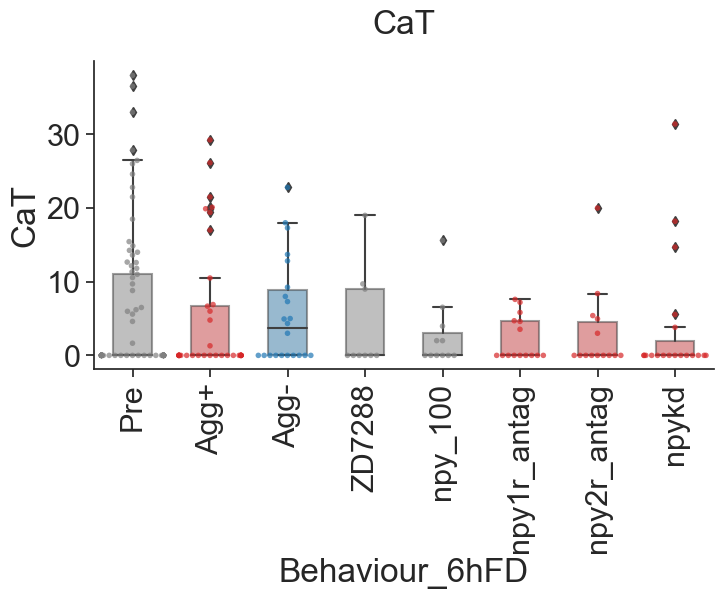

Ih_at_-120mV ('Pre', 'Agg+') 0.01567167308198443
Ih_at_-120mV ('Pre', 'Agg-') 0.5161858338475181
Ih_at_-120mV ('Pre', 'npy1r_antag') 0.895539682433509
Ih_at_-120mV ('Pre', 'npy2r_antag') 0.7451417893766555
Ih_at_-120mV ('Pre', 'npy_100') 0.024780518861118175
Ih_at_-120mV ('Pre', 'ZD7288') 0.00038696578446780085
Ih_at_-120mV ('Pre', 'npykd') 0.7826807726915641
Ih_at_-120mV ('Agg+', 'Agg-') 0.0016158303268119477
Ih_at_-120mV ('Agg+', 'npy1r_antag') 0.1546187835561628
Ih_at_-120mV ('Agg+', 'npy2r_antag') 0.09660398560372581
Ih_at_-120mV ('Agg+', 'npy_100') 0.3526060062350961
Ih_at_-120mV ('Agg+', 'ZD7288') 0.0022986562152895276
Ih_at_-120mV ('Agg+', 'npykd') 0.02157533219635939
Ih_at_-120mV ('Agg-', 'npy1r_antag') 0.5054880344356945
Ih_at_-120mV ('Agg-', 'npy2r_antag') 0.36334541130232734
Ih_at_-120mV ('Agg-', 'npy_100') 0.0025909920943359187
Ih_at_-120mV ('Agg-', 'ZD7288') 3.1739315352409464e-05
Ih_at_-120mV ('Agg-', 'npykd') 0.8650353939353734
Ih_at_-120mV ('npy1r_antag', 'npy2r_antag')

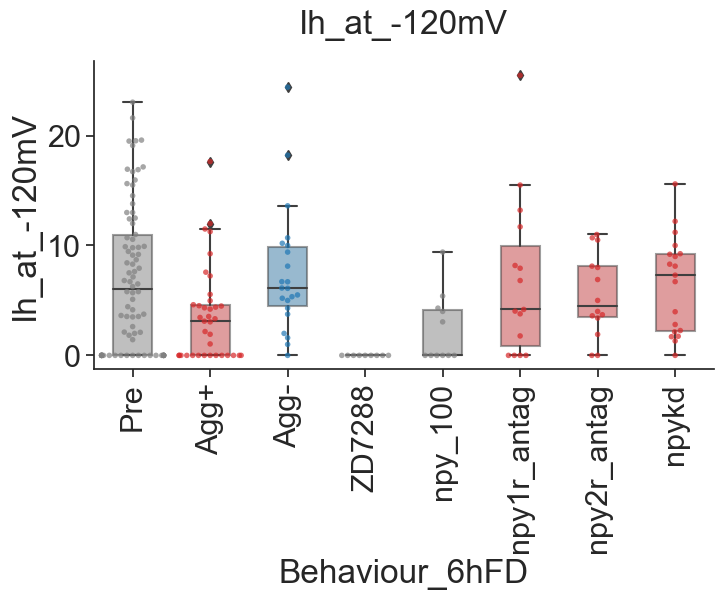

AP_ampl ('Pre', 'Agg+') 0.16247697288407315
AP_ampl ('Pre', 'Agg-') 0.6484995979902848
AP_ampl ('Pre', 'npy1r_antag') 0.0019617391708031686
AP_ampl ('Pre', 'npy2r_antag') 0.027046951901209967
AP_ampl ('Pre', 'npy_100') 0.28090491592935163
AP_ampl ('Pre', 'ZD7288') 0.6150079488107387
AP_ampl ('Pre', 'npykd') 0.013079101732619993
AP_ampl ('Agg+', 'Agg-') 0.6238297527107616
AP_ampl ('Agg+', 'npy1r_antag') 0.023507306342240308
AP_ampl ('Agg+', 'npy2r_antag') 0.315800607603425
AP_ampl ('Agg+', 'npy_100') 0.9660404455041509
AP_ampl ('Agg+', 'ZD7288') 0.9272326396088045
AP_ampl ('Agg+', 'npykd') 0.14356916737610206
AP_ampl ('Agg-', 'npy1r_antag') 0.006323780925748658
AP_ampl ('Agg-', 'npy2r_antag') 0.09459935246991134
AP_ampl ('Agg-', 'npy_100') 0.3420369104579631
AP_ampl ('Agg-', 'ZD7288') 0.8421052631578947
AP_ampl ('Agg-', 'npykd') 0.07117241510559746
AP_ampl ('npy1r_antag', 'npy2r_antag') 0.695894823170777
AP_ampl ('npy1r_antag', 'npy_100') 0.21208791208791208
AP_ampl ('npy1r_antag', 'ZD7

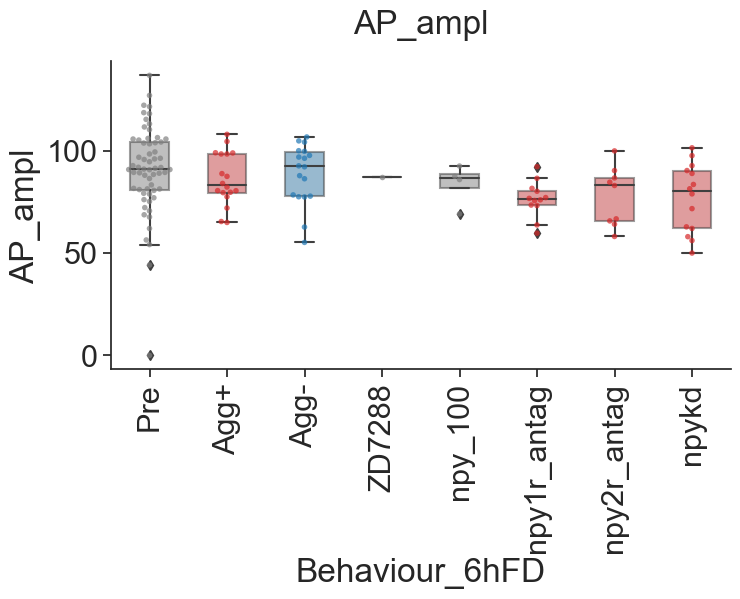

AP_halfwidth ('Pre', 'Agg+') 0.8078762185233178
AP_halfwidth ('Pre', 'Agg-') 0.04959538934130666
AP_halfwidth ('Pre', 'npy1r_antag') 0.8858255259367204
AP_halfwidth ('Pre', 'npy2r_antag') 0.7618762343914461
AP_halfwidth ('Pre', 'npy_100') 0.30465553268201717
AP_halfwidth ('Pre', 'ZD7288') 0.7332069215467361
AP_halfwidth ('Pre', 'npykd') 0.3920268022551605
AP_halfwidth ('Agg+', 'Agg-') 0.11308428312664967
AP_halfwidth ('Agg+', 'npy1r_antag') 0.9493232531294364
AP_halfwidth ('Agg+', 'npy2r_antag') 0.661777796287998
AP_halfwidth ('Agg+', 'npy_100') 0.327470542946215
AP_halfwidth ('Agg+', 'ZD7288') 1.0
AP_halfwidth ('Agg+', 'npykd') 0.6078780112074706
AP_halfwidth ('Agg-', 'npy1r_antag') 0.18847057213355278
AP_halfwidth ('Agg-', 'npy2r_antag') 0.3672599040677643
AP_halfwidth ('Agg-', 'npy_100') 0.9659827751335944
AP_halfwidth ('Agg-', 'ZD7288') 0.6473550172983791
AP_halfwidth ('Agg-', 'npykd') 0.022468620794247395
AP_halfwidth ('npy1r_antag', 'npy2r_antag') 0.9149684068240318
AP_halfwidth 

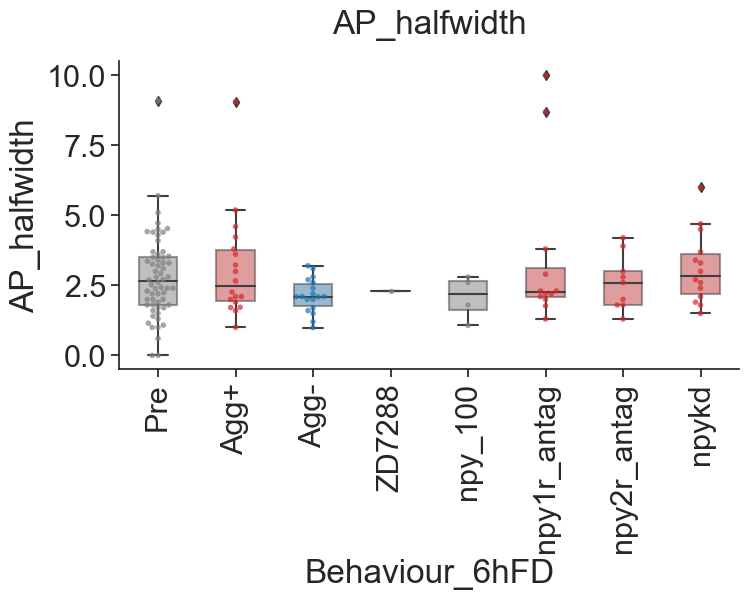

AP_time_to_peak ('Pre', 'Agg+') 0.3316689692537328
AP_time_to_peak ('Pre', 'Agg-') 0.8469049089292453
AP_time_to_peak ('Pre', 'npy1r_antag') 0.03377040596934124
AP_time_to_peak ('Pre', 'npy2r_antag') 0.3384337418563298
AP_time_to_peak ('Pre', 'npy_100') 0.3529626590041691
AP_time_to_peak ('Pre', 'ZD7288') 0.48448574129036415
AP_time_to_peak ('Pre', 'npykd') 0.05672707790054181
AP_time_to_peak ('Agg+', 'Agg-') 0.33383971722293626
AP_time_to_peak ('Agg+', 'npy1r_antag') 0.030589497315917136
AP_time_to_peak ('Agg+', 'npy2r_antag') 0.12866063335500122
AP_time_to_peak ('Agg+', 'npy_100') 0.24967136705437742
AP_time_to_peak ('Agg+', 'ZD7288') 0.9271048846803653
AP_time_to_peak ('Agg+', 'npykd') 0.04392758270620745
AP_time_to_peak ('Agg-', 'npy1r_antag') 0.004385123090463345
AP_time_to_peak ('Agg-', 'npy2r_antag') 0.27772782379138483
AP_time_to_peak ('Agg-', 'npy_100') 0.15837452562515886
AP_time_to_peak ('Agg-', 'ZD7288') 0.40904435007858275
AP_time_to_peak ('Agg-', 'npykd') 0.03791172382938

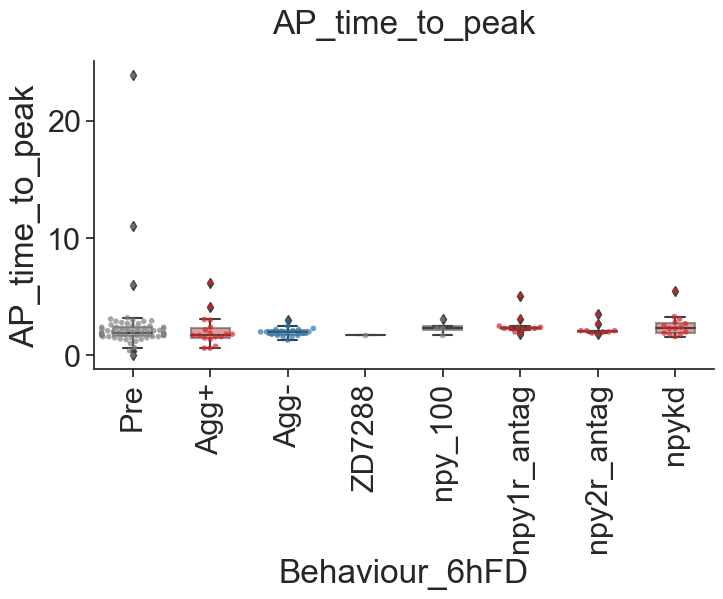

area(mV_ms) ('Pre', 'Agg+') 0.3935218230145785
area(mV_ms) ('Pre', 'Agg-') 0.016837642364698622
area(mV_ms) ('Pre', 'npy1r_antag') 0.2426447163920502
area(mV_ms) ('Pre', 'npy2r_antag') 0.05809609163377846
area(mV_ms) ('Pre', 'npy_100') 0.2572726757926964
area(mV_ms) ('Pre', 'ZD7288') 0.538761861912151
area(mV_ms) ('Pre', 'npykd') 0.22361441127917991
area(mV_ms) ('Agg+', 'Agg-') 0.579776556930091
area(mV_ms) ('Agg+', 'npy1r_antag') 0.8821981118675254
area(mV_ms) ('Agg+', 'npy2r_antag') 0.45571974291670336
area(mV_ms) ('Agg+', 'npy_100') 0.8314250544479901
area(mV_ms) ('Agg+', 'ZD7288') 0.9272326396088045
area(mV_ms) ('Agg+', 'npykd') 1.0
area(mV_ms) ('Agg-', 'npy1r_antag') 0.9831126875838702
area(mV_ms) ('Agg-', 'npy2r_antag') 0.6251055995506551
area(mV_ms) ('Agg-', 'npy_100') 0.9022556390977444
area(mV_ms) ('Agg-', 'ZD7288') 1.0
area(mV_ms) ('Agg-', 'npykd') 0.19001098064722566
area(mV_ms) ('npy1r_antag', 'npy2r_antag') 0.45554509378932984
area(mV_ms) ('npy1r_antag', 'npy_100') 1.0
are

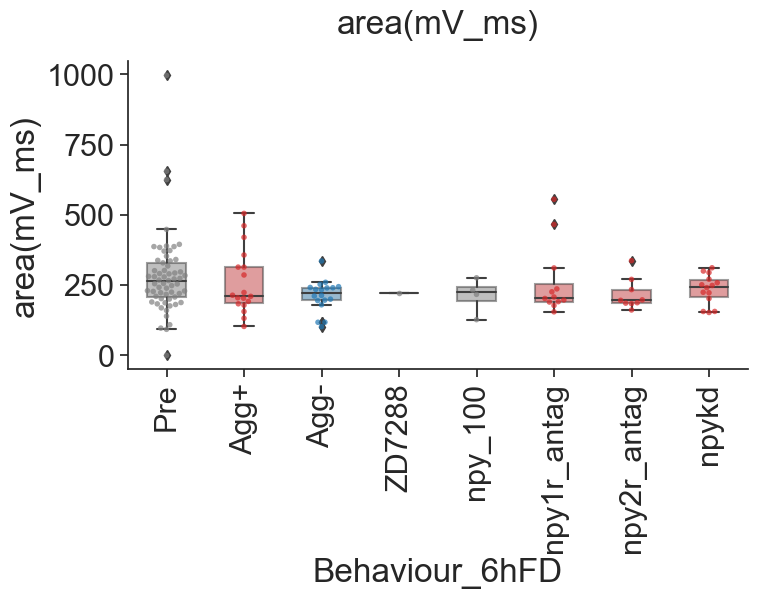

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.04622308047377383
rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 0.14643851650205936
rheobase_at_-60mV_(pA) ('Pre', 'npy1r_antag') 0.21018602260282315
rheobase_at_-60mV_(pA) ('Pre', 'npy2r_antag') 0.5581361076903046
rheobase_at_-60mV_(pA) ('Pre', 'npy_100') 0.0014632605186238332
rheobase_at_-60mV_(pA) ('Pre', 'ZD7288') 0.03158113135357213
rheobase_at_-60mV_(pA) ('Pre', 'npykd') 0.15986948030466852
rheobase_at_-60mV_(pA) ('Agg+', 'Agg-') 0.6349376166436531
rheobase_at_-60mV_(pA) ('Agg+', 'npy1r_antag') 0.7141135965776519
rheobase_at_-60mV_(pA) ('Agg+', 'npy2r_antag') 0.39791091224607444
rheobase_at_-60mV_(pA) ('Agg+', 'npy_100') 0.11510834017263796
rheobase_at_-60mV_(pA) ('Agg+', 'ZD7288') 0.004493951979789224
rheobase_at_-60mV_(pA) ('Agg+', 'npykd') 0.32728895021831295
rheobase_at_-60mV_(pA) ('Agg-', 'npy1r_antag') 1.0
rheobase_at_-60mV_(pA) ('Agg-', 'npy2r_antag') 0.7741936507867566
rheobase_at_-60mV_(pA) ('Agg-', 'npy_100') 0.04054050050326848
rheobas

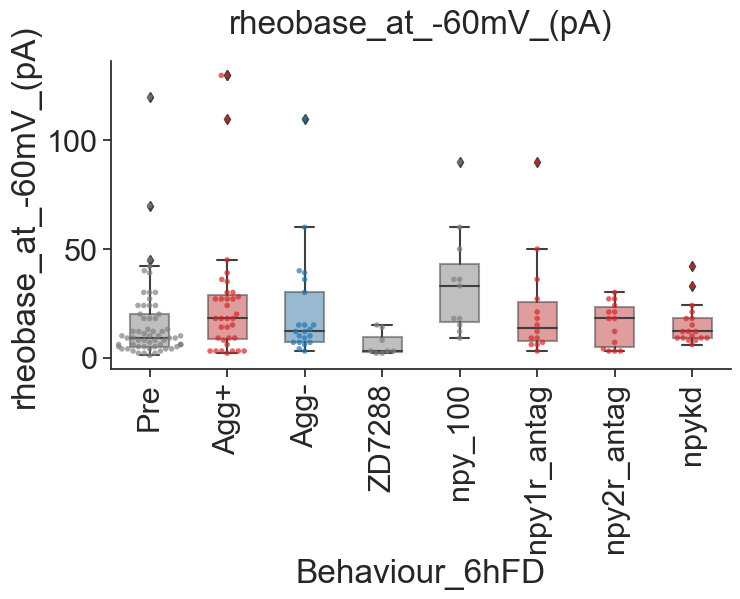

AHP_(mV) ('Pre', 'Agg+') 0.43027600323735005
AHP_(mV) ('Pre', 'Agg-') 0.682407498428275
AHP_(mV) ('Pre', 'npy1r_antag') 0.1042686796936504
AHP_(mV) ('Pre', 'npy2r_antag') 0.5991265521896039
AHP_(mV) ('Pre', 'npy_100') 0.2732448073074579
AHP_(mV) ('Pre', 'ZD7288') 0.9547027682916275
AHP_(mV) ('Pre', 'npykd') 1.9186906844469742e-06
AHP_(mV) ('Agg+', 'Agg-') 0.579776556930091
AHP_(mV) ('Agg+', 'npy1r_antag') 0.1688254180539409
AHP_(mV) ('Agg+', 'npy2r_antag') 0.8976696123456875
AHP_(mV) ('Agg+', 'npy_100') 0.7656848937006044
AHP_(mV) ('Agg+', 'ZD7288') 0.4648169025699824
AHP_(mV) ('Agg+', 'npykd') 4.7962679358246774e-05
AHP_(mV) ('Agg-', 'npy1r_antag') 0.13279539648494482
AHP_(mV) ('Agg-', 'npy2r_antag') 0.8369711950016507
AHP_(mV) ('Agg-', 'npy_100') 0.43417634996582366
AHP_(mV) ('Agg-', 'ZD7288') 0.8421052631578947
AHP_(mV) ('Agg-', 'npykd') 2.280084288246825e-05
AHP_(mV) ('npy1r_antag', 'npy2r_antag') 0.39361500571651586
AHP_(mV) ('npy1r_antag', 'npy_100') 1.0
AHP_(mV) ('npy1r_antag', 

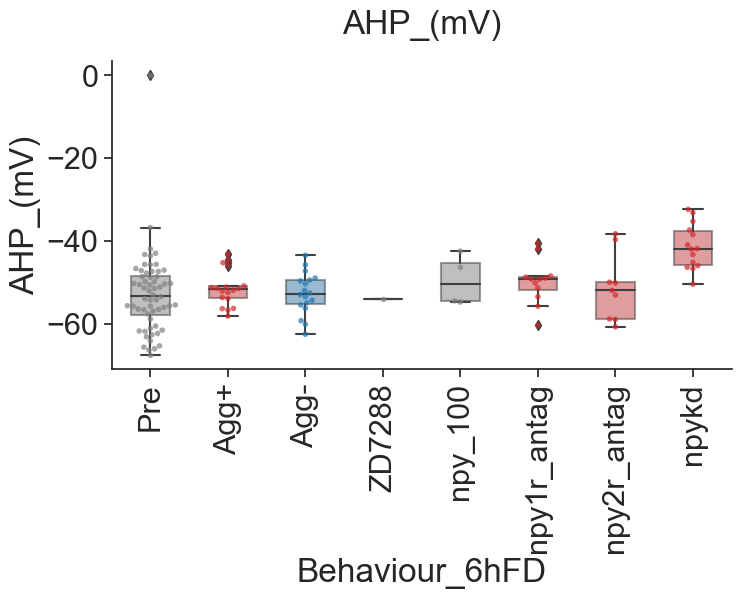

Vm ('Pre', 'Agg+') 0.3878702225978521
Vm ('Pre', 'Agg-') 0.5059726708502595
Vm ('Pre', 'npy1r_antag') 0.06155381242762307
Vm ('Pre', 'npy2r_antag') 0.567011630483742
Vm ('Pre', 'npy_100') 0.8753209216358904
Vm ('Pre', 'ZD7288') 0.05696856621362753
Vm ('Pre', 'npykd') 2.454085315453548e-07
Vm ('Agg+', 'Agg-') 0.8159167726404731
Vm ('Agg+', 'npy1r_antag') 0.3954718746902113
Vm ('Agg+', 'npy2r_antag') 0.846863564559653
Vm ('Agg+', 'npy_100') 0.4536024488894459
Vm ('Agg+', 'ZD7288') 0.2560341287713688
Vm ('Agg+', 'npykd') 7.002918995088272e-05
Vm ('Agg-', 'npy1r_antag') 0.15927452165285128
Vm ('Agg-', 'npy2r_antag') 0.6989930202150316
Vm ('Agg-', 'npy_100') 0.3494577006995545
Vm ('Agg-', 'ZD7288') 0.1572500789959627
Vm ('Agg-', 'npykd') 0.0001423765574549236
Vm ('npy1r_antag', 'npy2r_antag') 0.3400858902842717
Vm ('npy1r_antag', 'npy_100') 0.19445981020349767
Vm ('npy1r_antag', 'ZD7288') 0.8580276569875211
Vm ('npy1r_antag', 'npykd') 0.0031965719549487096
Vm ('npy2r_antag', 'npy_100') 0.67

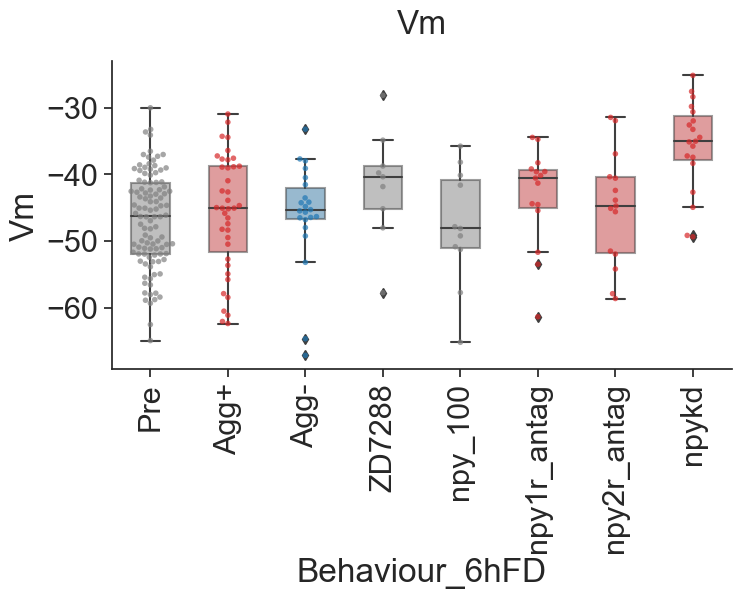

Input_Resistance ('Pre', 'Agg+') 0.012063552838474939
Input_Resistance ('Pre', 'Agg-') 0.7897476721570257
Input_Resistance ('Pre', 'npy1r_antag') 0.20332306298223934
Input_Resistance ('Pre', 'npy2r_antag') 0.5367968840449264
Input_Resistance ('Pre', 'npy_100') 0.9952539650482173
Input_Resistance ('Pre', 'ZD7288') 0.0012071520714673186
Input_Resistance ('Pre', 'npykd') 0.0003159029724099908
Input_Resistance ('Agg+', 'Agg-') 0.04780410973365508
Input_Resistance ('Agg+', 'npy1r_antag') 0.528361027072211
Input_Resistance ('Agg+', 'npy2r_antag') 0.28481658670683874
Input_Resistance ('Agg+', 'npy_100') 0.29707487279187705
Input_Resistance ('Agg+', 'ZD7288') 0.048600745260113744
Input_Resistance ('Agg+', 'npykd') 0.09793827997127597
Input_Resistance ('Agg-', 'npy1r_antag') 0.24603234909826666
Input_Resistance ('Agg-', 'npy2r_antag') 0.57009529631342
Input_Resistance ('Agg-', 'npy_100') 0.8336348830246822
Input_Resistance ('Agg-', 'ZD7288') 0.0021541104518153133
Input_Resistance ('Agg-', 'npyk

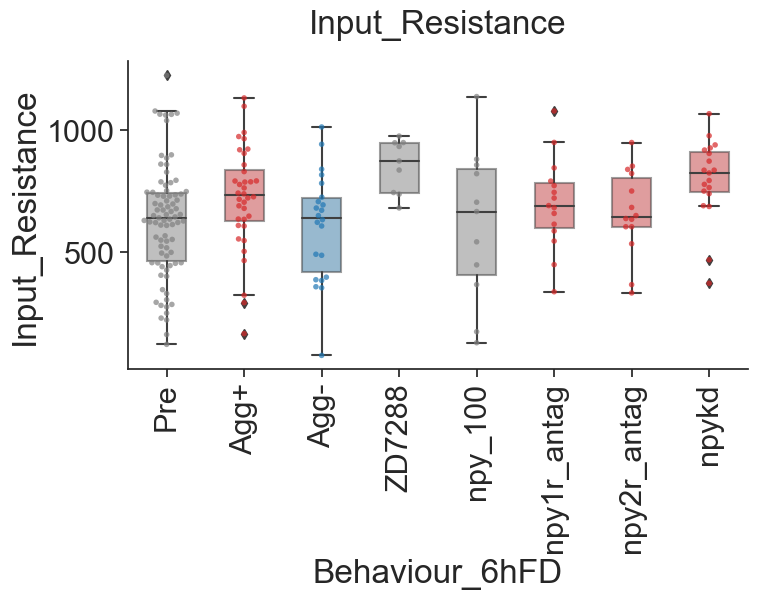

sPSC_frequency ('Pre', 'Agg+') 0.7827575108101945
sPSC_frequency ('Pre', 'Agg-') 0.16569340327720272
sPSC_frequency ('Pre', 'npy1r_antag') 0.007897739636139703
sPSC_frequency ('Pre', 'npy2r_antag') 0.08584407405594864
sPSC_frequency ('Pre', 'npy_100') 0.8002711267760505
sPSC_frequency ('Pre', 'ZD7288') 0.00012029387794381674
sPSC_frequency ('Pre', 'npykd') 0.20804138748350864
sPSC_frequency ('Agg+', 'Agg-') 0.1693520783697472
sPSC_frequency ('Agg+', 'npy1r_antag') 0.021550780959905078
sPSC_frequency ('Agg+', 'npy2r_antag') 0.1732643578396097
sPSC_frequency ('Agg+', 'npy_100') 0.7190640828128434
sPSC_frequency ('Agg+', 'ZD7288') 0.0007175728269851531
sPSC_frequency ('Agg+', 'npykd') 0.39912425542133956
sPSC_frequency ('Agg-', 'npy1r_antag') 0.0015203172563771129
sPSC_frequency ('Agg-', 'npy2r_antag') 0.00988652142502657
sPSC_frequency ('Agg-', 'npy_100') 0.33936996262299535
sPSC_frequency ('Agg-', 'ZD7288') 0.0016887282854299345
sPSC_frequency ('Agg-', 'npykd') 0.03712596135002326
sPSC_

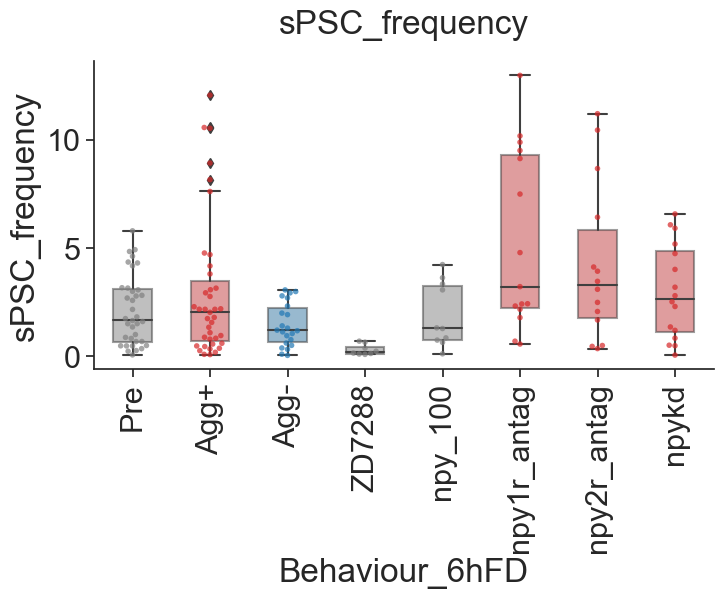

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.683055463150525
sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.025875307502539382
sPSC_Amplitude(pA) ('Pre', 'npy1r_antag') 0.5216038164206143
sPSC_Amplitude(pA) ('Pre', 'npy2r_antag') 0.871256554144888
sPSC_Amplitude(pA) ('Pre', 'npy_100') 0.9681326147794604
sPSC_Amplitude(pA) ('Pre', 'ZD7288') 0.002009908114278183
sPSC_Amplitude(pA) ('Pre', 'npykd') 0.11270055095908209
sPSC_Amplitude(pA) ('Agg+', 'Agg-') 0.036768552095251386
sPSC_Amplitude(pA) ('Agg+', 'npy1r_antag') 0.6709329006428086
sPSC_Amplitude(pA) ('Agg+', 'npy2r_antag') 0.9036530584449858
sPSC_Amplitude(pA) ('Agg+', 'npy_100') 0.9209554024984805
sPSC_Amplitude(pA) ('Agg+', 'ZD7288') 0.0025717016251768344
sPSC_Amplitude(pA) ('Agg+', 'npykd') 0.15359987852386717
sPSC_Amplitude(pA) ('Agg-', 'npy1r_antag') 0.7451488435418439
sPSC_Amplitude(pA) ('Agg-', 'npy2r_antag') 0.21685720304576017
sPSC_Amplitude(pA) ('Agg-', 'npy_100') 0.16598539740736384
sPSC_Amplitude(pA) ('Agg-', 'ZD7288') 0.013642787090909672


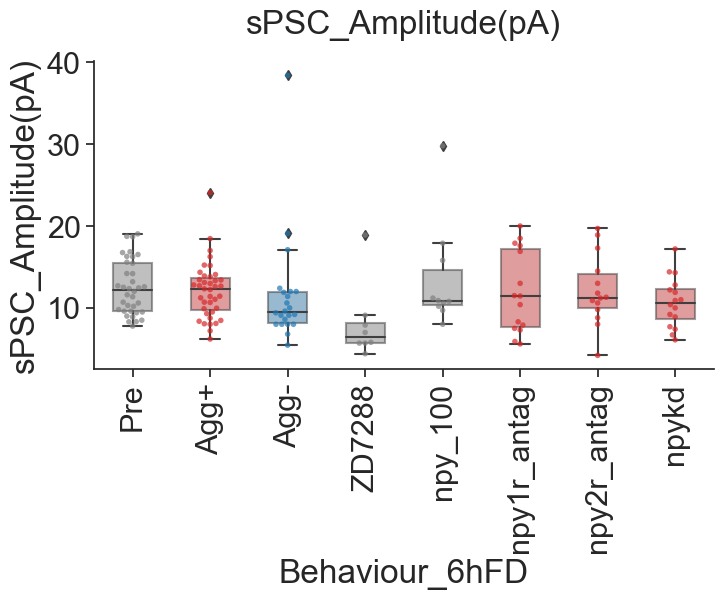

sPSCs_Rise time ('Pre', 'Agg+') 0.950036843115982
sPSCs_Rise time ('Pre', 'Agg-') 0.3970241676687203
sPSCs_Rise time ('Pre', 'npy1r_antag') 0.9820976399517795
sPSCs_Rise time ('Pre', 'npy2r_antag') 0.526527081616134
sPSCs_Rise time ('Pre', 'npy_100') 0.8961597102021173
sPSCs_Rise time ('Pre', 'ZD7288') 0.5400376799085684
sPSCs_Rise time ('Pre', 'npykd') 0.5689142610570352
sPSCs_Rise time ('Agg+', 'Agg-') 0.393417522946769
sPSCs_Rise time ('Agg+', 'npy1r_antag') 0.8304584143207073
sPSCs_Rise time ('Agg+', 'npy2r_antag') 0.6185720325122499
sPSCs_Rise time ('Agg+', 'npy_100') 0.8611278415174022
sPSCs_Rise time ('Agg+', 'ZD7288') 0.6286295180767305
sPSCs_Rise time ('Agg+', 'npykd') 0.6343334058547931
sPSCs_Rise time ('Agg-', 'npy1r_antag') 0.29648351958617036
sPSCs_Rise time ('Agg-', 'npy2r_antag') 0.7069776604114097
sPSCs_Rise time ('Agg-', 'npy_100') 0.42418306412830675
sPSCs_Rise time ('Agg-', 'ZD7288') 0.620780270779305
sPSCs_Rise time ('Agg-', 'npykd') 0.8003315640351998
sPSCs_Rise ti

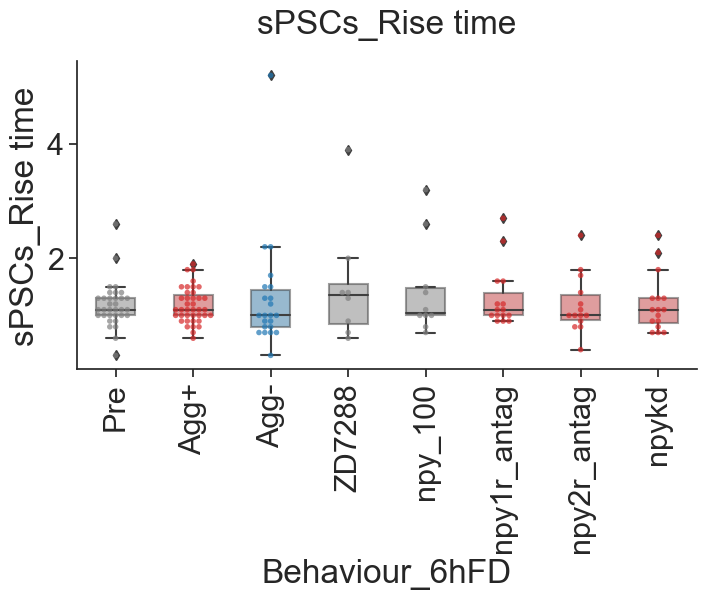

sPSCs (decay) ('Pre', 'Agg+') 0.4880522094114421
sPSCs (decay) ('Pre', 'Agg-') 0.5852881642217079
sPSCs (decay) ('Pre', 'npy1r_antag') 0.18937115235964863
sPSCs (decay) ('Pre', 'npy2r_antag') 0.4100454946750728
sPSCs (decay) ('Pre', 'npy_100') 0.28413078196034824
sPSCs (decay) ('Pre', 'ZD7288') 0.33514868886616145
sPSCs (decay) ('Pre', 'npykd') 0.457048180309247
sPSCs (decay) ('Agg+', 'Agg-') 0.956738954896584
sPSCs (decay) ('Agg+', 'npy1r_antag') 0.3795525545460817
sPSCs (decay) ('Agg+', 'npy2r_antag') 0.6865854689159321
sPSCs (decay) ('Agg+', 'npy_100') 0.4922031287746381
sPSCs (decay) ('Agg+', 'ZD7288') 0.30783177866375866
sPSCs (decay) ('Agg+', 'npykd') 0.42014667955978635
sPSCs (decay) ('Agg-', 'npy1r_antag') 0.2752236364320767
sPSCs (decay) ('Agg-', 'npy2r_antag') 0.6016296673363777
sPSCs (decay) ('Agg-', 'npy_100') 0.6506095034649881
sPSCs (decay) ('Agg-', 'ZD7288') 0.3536940897929446
sPSCs (decay) ('Agg-', 'npykd') 0.6344757646596549
sPSCs (decay) ('npy1r_antag', 'npy2r_antag')

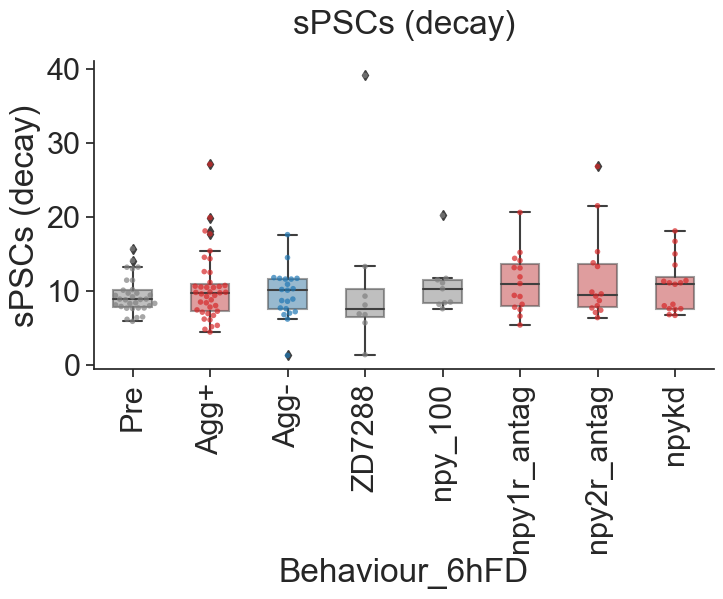

In [358]:
filter_cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100', 'npy1r_antag', 'npy2r_antag', 'npykd']


preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)],'Behaviour_6hFD', 'pan', 
                palette=['Gray', 'Tab:red', 'Tab:Blue', 'Gray', 'Gray', 'Tab:red', 'Tab:red', 'Tab:red'], order = filter_cat,
                  plotting= True)


Cm(pF) ('yes', 'no') 0.7301587301587302
Gal_positive
no     48.160853
yes    43.144010
Name: Cm(pF), dtype: float64


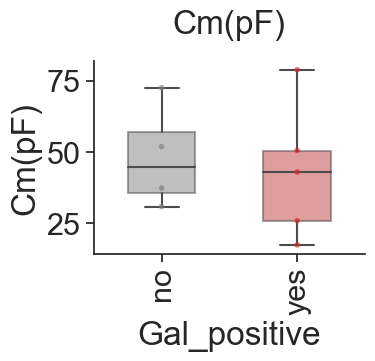

Firing_freq_(Hz)_I0 ('yes', 'no') 0.9623792965147909
Gal_positive
no     1.326
yes    0.740
Name: Firing_freq_(Hz)_I0, dtype: float64


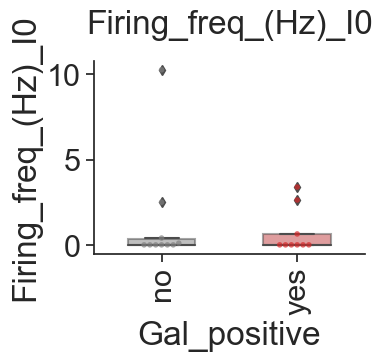

Instant_freq_(Hz) ('yes', 'no') 0.9623792965147909
Gal_positive
no     1.470000
yes    0.871111
Name: Instant_freq_(Hz), dtype: float64


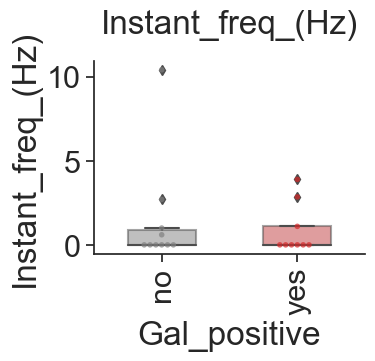

isi_(ms) ('yes', 'no') 0.6285714285714286
Gal_positive
no     3117.855000
yes     740.333333
Name: isi_(ms), dtype: float64


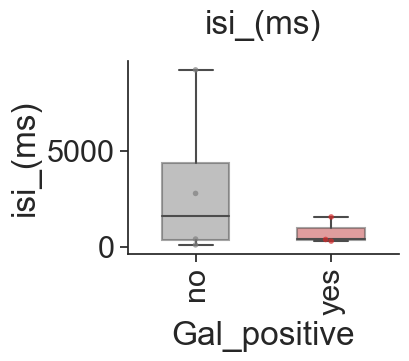

CaT ('yes', 'no') 0.1865490284851945
Gal_positive
no     8.533000
yes    1.842857
Name: CaT, dtype: float64


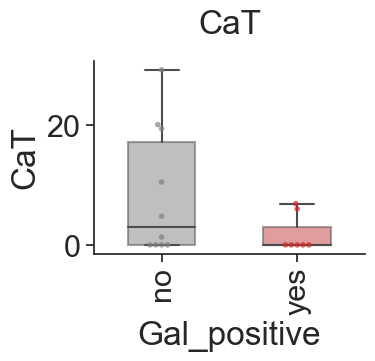

Ih_at_-120mV ('yes', 'no') 0.6146465622110426
Gal_positive
no     3.84400
yes    4.52875
Name: Ih_at_-120mV, dtype: float64


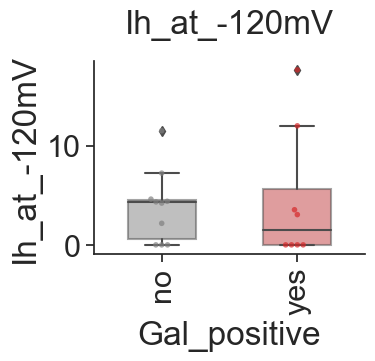

AP_ampl ('yes', 'no') 0.11428571428571428
Gal_positive
no     86.800000
yes    70.266667
Name: AP_ampl, dtype: float64


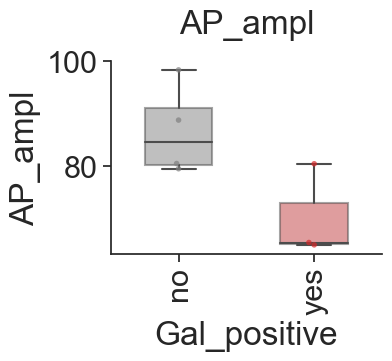

AP_halfwidth ('yes', 'no') 0.05714285714285714
Gal_positive
no     1.927500
yes    3.613333
Name: AP_halfwidth, dtype: float64


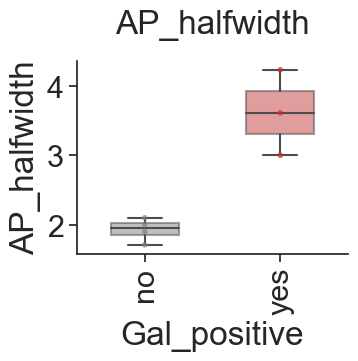

AP_time_to_peak ('yes', 'no') 0.4
Gal_positive
no     1.505000
yes    2.026667
Name: AP_time_to_peak, dtype: float64


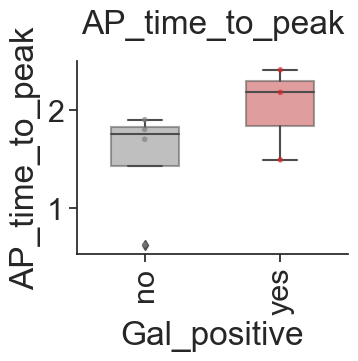

area(mV_ms) ('yes', 'no') 0.22857142857142856
Gal_positive
no     179.475000
yes    240.766667
Name: area(mV_ms), dtype: float64


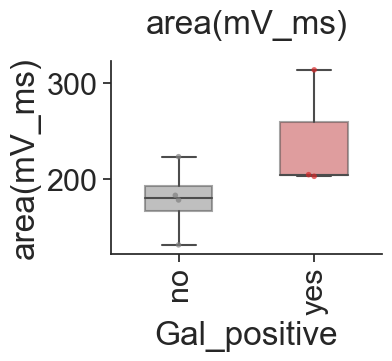

rheobase_at_-60mV_(pA) ('yes', 'no') 0.7109480668548791
Gal_positive
no     44.625
yes    20.500
Name: rheobase_at_-60mV_(pA), dtype: float64


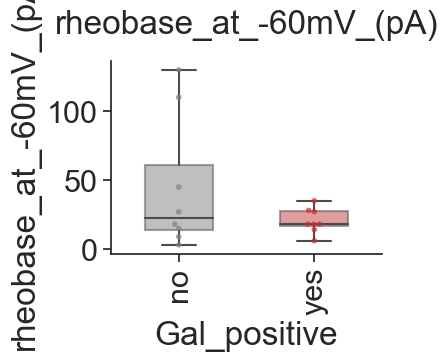

AHP_(mV) ('yes', 'no') 0.05714285714285714
Gal_positive
no    -52.450000
yes   -44.816667
Name: AHP_(mV), dtype: float64


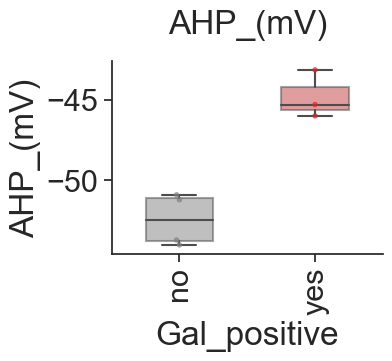

Vm ('yes', 'no') 0.11134688653314041
Gal_positive
no    -46.908149
yes   -39.845540
Name: Vm, dtype: float64


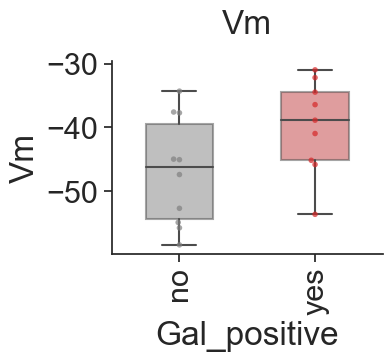

Input_Resistance ('yes', 'no') 1.0
Gal_positive
no     665.622933
yes    680.159409
Name: Input_Resistance, dtype: float64


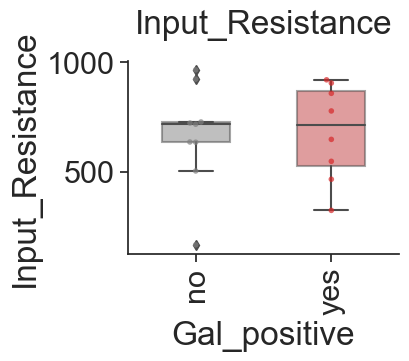

sPSC_frequency ('yes', 'no') 0.25099827044292256
Gal_positive
no     4.908518
yes    2.964686
Name: sPSC_frequency, dtype: float64


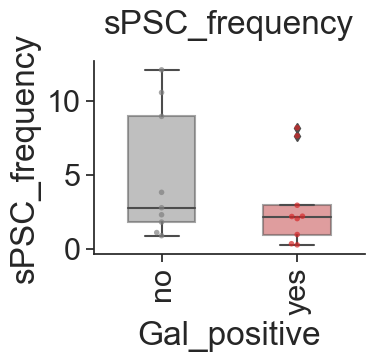

sPSC_Amplitude(pA) ('yes', 'no') 0.47992869214595724
Gal_positive
no     12.370000
yes    10.981111
Name: sPSC_Amplitude(pA), dtype: float64


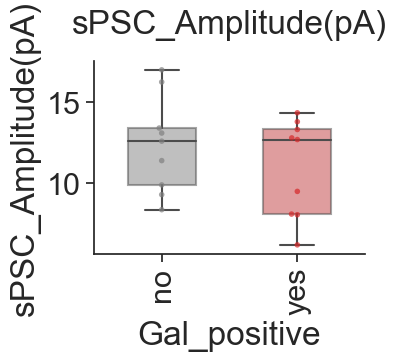

sPSCs_Rise time ('yes', 'no') 0.6546448519368657
Gal_positive
no     1.066667
yes    1.188889
Name: sPSCs_Rise time, dtype: float64


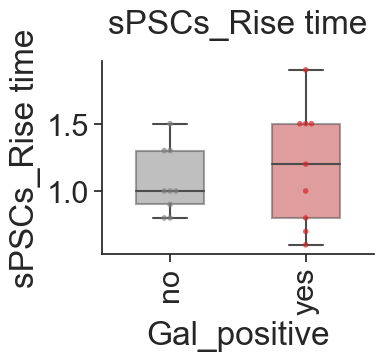

sPSCs (decay) ('yes', 'no') 0.052058768750600205
Gal_positive
no      9.096667
yes    12.294444
Name: sPSCs (decay), dtype: float64


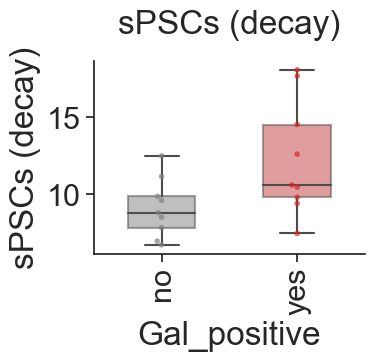

In [218]:
preprocess_plot(ephys[(ephys.Gal_positive.isin(['no', 'yes'])) & (ephys.Behaviour_6hFD.isin(['Agg-', 'Agg+']))], 
                'Gal_positive', 'gal', palette=['Gray', 'Tab:red'], order = ['no', 'yes'], plotting= True)


Cm(pF) nan
Firing_freq_(Hz)_I0 nan
Instant_freq_(Hz) nan
isi_(ms) nan
CaT nan
Ih_at_-120mV nan
AP_ampl nan
AP_halfwidth nan
AP_time_to_peak nan
area(mV_ms) nan
rheobase_at_-60mV_(pA) nan
AHP_(mV) nan
Vm nan
Input_Resistance nan
sPSC_frequency nan
sPSC_Amplitude(pA) nan
sPSCs_Rise time nan
sPSCs (decay) nan
AC-I0 nan
AC_-60 nan


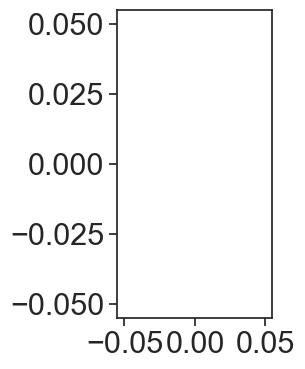

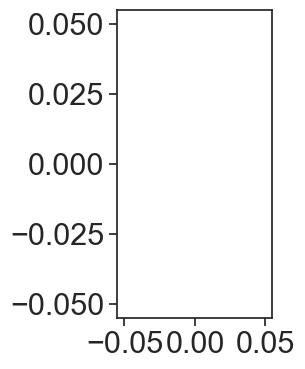

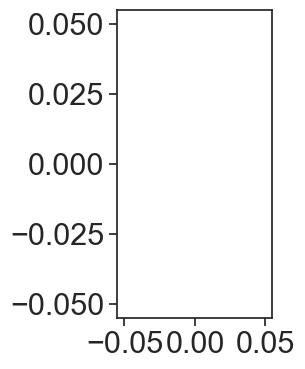

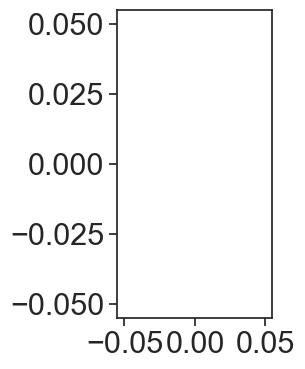

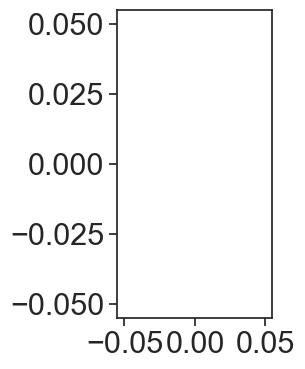

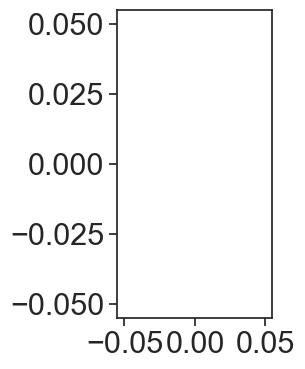

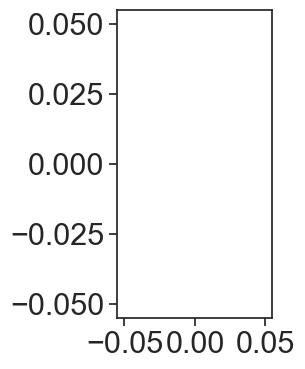

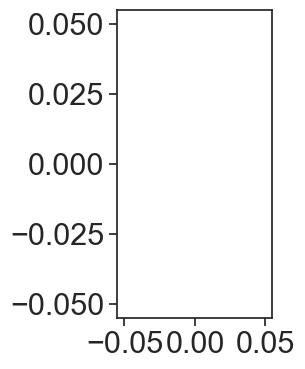

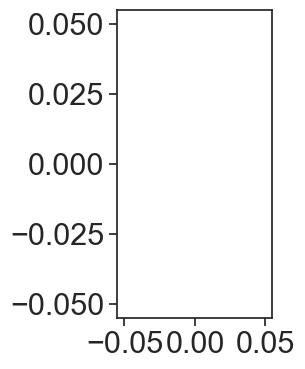

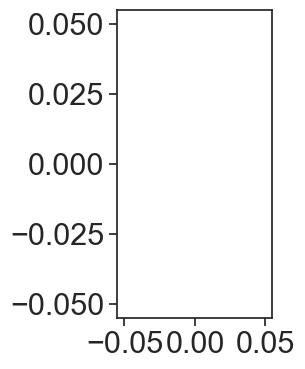

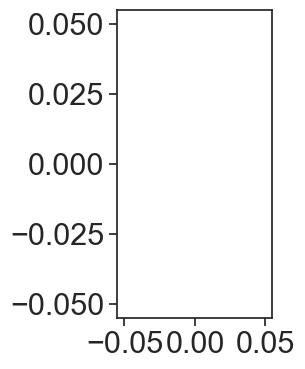

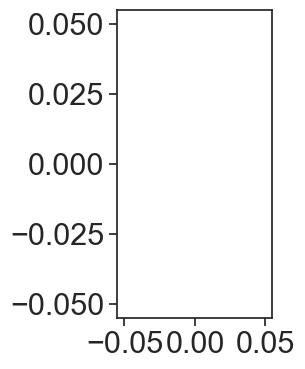

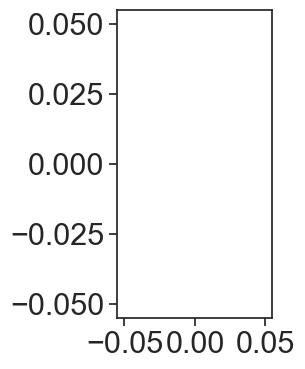

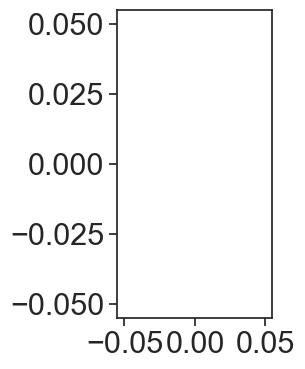

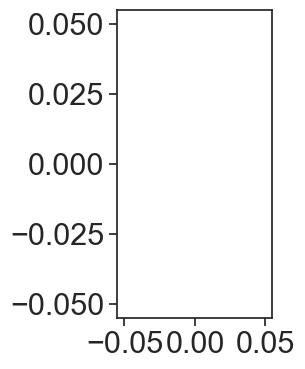

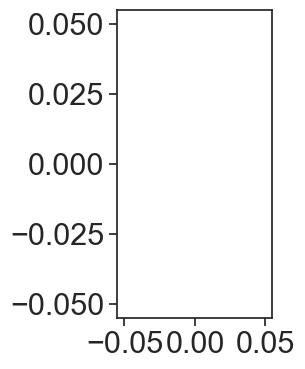

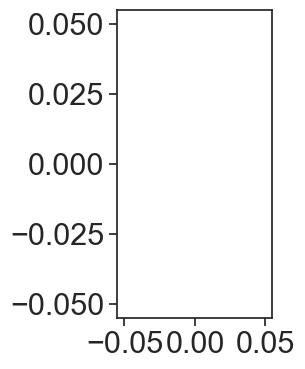

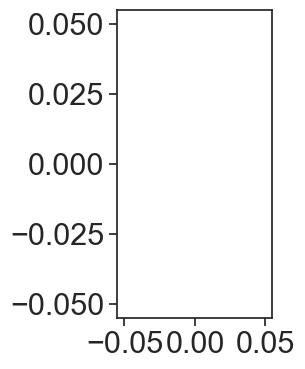

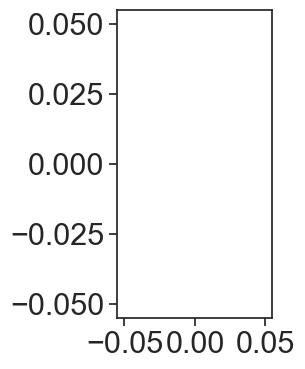

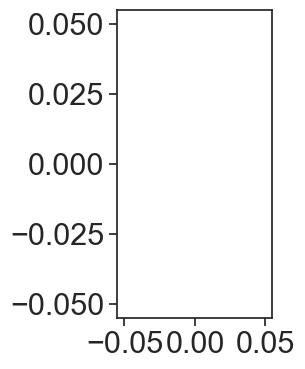

In [194]:
gals = pd.concat([gal,no_gal], axis = 0)
gals = gals[gals.Behaviour_6hFD.isin(['Agg+', 'Agg-'])]

ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
   'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    try:
        _, p = stats.ttest_ind(gals[(gals.Gal_positive == 'yes')][column].dropna(),
                                    gals[(gals.Gal_positive == 'no')][column].dropna(),
                                    equal_var = False)
        print(column , p)


        gals[column] = pd.to_numeric(gals[column])
        fig,ax = plt.subplots(figsize = (2,4))
        sns.swarmplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'])
        sns.boxplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
        sns.despine()
        plt.title(column + '_' + str(p)[:3])
        plt.savefig(f'output_figures/gal_nogal_{column}.png',dpi = 300, bbox_inches = 'tight')
        plt.show()
    except Exception:
        continue

In [135]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 
                              'Firing_freq_(Hz)_I0': 'firing_freq', 
                              'sPSC_Amplitude(pA)': 'sPSC_Amplitude'})
model = smf.ols('Input_Resistance ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,4.356598e+05,1.0,9.260938,0.002807
Residual,6.444854e+06,137.0,NaN,NaN


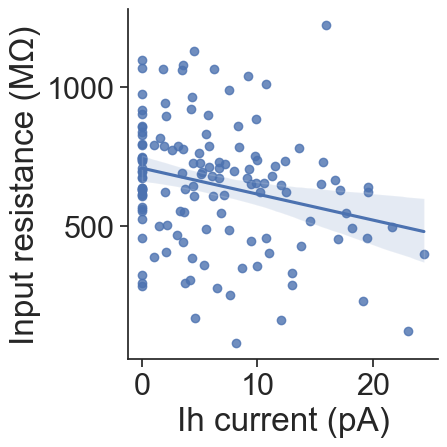

In [136]:
sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'])
plt.xlabel('Ih current (pA)')
plt.ylabel('Input resistance (MΩ)')
plt.savefig(f'output_figures/ih_input_resistance.png',dpi = 300, bbox_inches = 'tight')
          


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


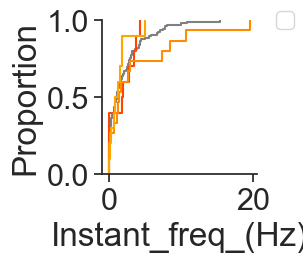

In [137]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['orange', 'darkorange', 'orangered', 'gray']
conds = ['npy_10', 'npy1r_antag', 'npy2r_antag', 'Pre']
fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", hue_order = conds, palette = cs, ax = ax, )
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


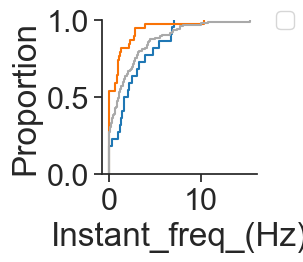

In [138]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']
fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

## silent prop

I_zero_reclassified  phasic  silent  tonic  All
Behaviour_6hFD                                 
Agg+                      7      21     11   39
Agg-                      4       4     14   22
Pre                      19      28     58  105
ZD7288                    0       8      1    9
npy1r_antag               2       3     10   15
npy2r_antag               3       4      3   10
npy_100                   2       7      2   11
npykd                     3       5     11   19
All                      40      80    110  230
0.001827760795378033


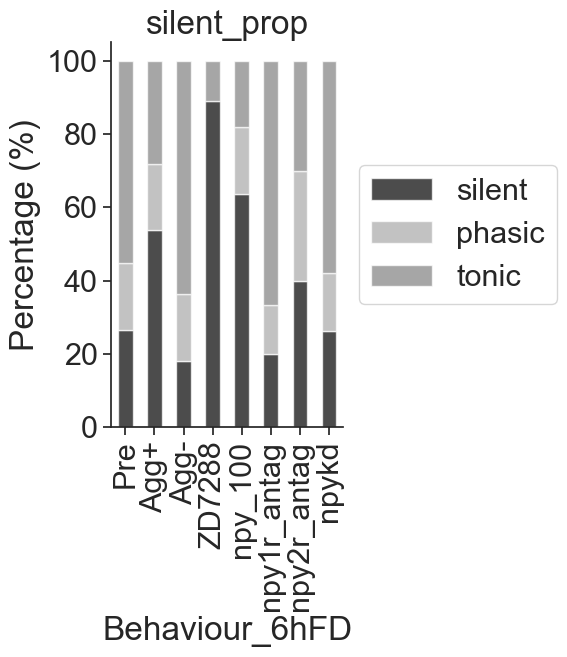

In [167]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100',  'npy1r_antag', 'npy2r_antag', 'npykd']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero_reclassified', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [168]:
silent_df = silent_prop.loc[:, ['Behaviour_6hFD', 'silent']]

In [169]:
silent_df

I_zero_reclassified,Behaviour_6hFD,silent
2,Pre,26.666667
0,Agg+,53.846154
1,Agg-,18.181818
3,ZD7288,88.888889
6,npy_100,63.636364
4,npy1r_antag,20.000000
5,npy2r_antag,40.000000
7,npykd,26.315789


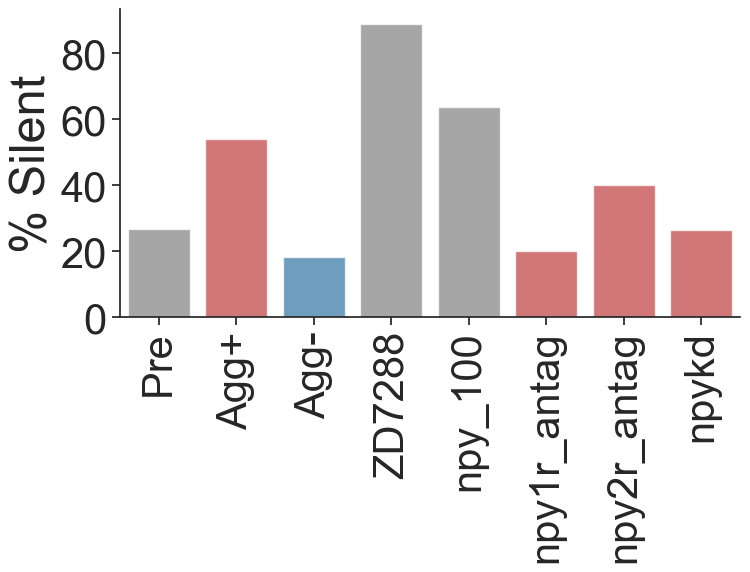

In [182]:
plt.subplots(figsize = (8,4))
sns.barplot(x = 'Behaviour_6hFD', y = 'silent', data = silent_df, palette = ['gray', 'Tab:red', 'Tab:blue', 'gray', 'gray', 'Tab:red', 'Tab:red', 'Tab:red'], alpha = 0.7)
plt.xticks(fontsize = 30, rotation = 90)
ax = plt.gca()
plt.ylabel('% Silent', fontsize = 35)
plt.yticks(fontsize = 30)
plt.xlabel('')



ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('output_figures/silent_prop.pdf',dpi = 300, bbox_inches = 'tight')

In [140]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

Empty DataFrame
Columns: []
Index: []


ValueError: No data; `observed` has size 0.

## adaptive prop

Adaptive        ?  no  no   yes  All
Behaviour_6hFD                      
Agg+            1  15    0   20   36
Agg-            0  18    0    3   21
Pre             1  15    0   27   43
npykd           0   9    1    9   19
All             2  57    1   59  119
0.01079291852916356


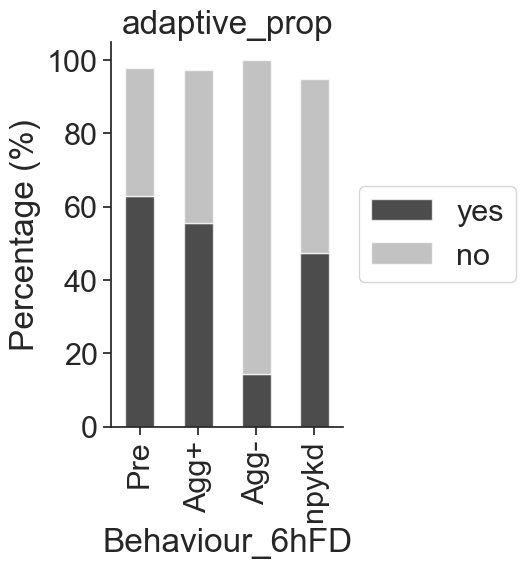

In [100]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-', 'npykd']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])

prop_plot(ad_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('adaptive_prop')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

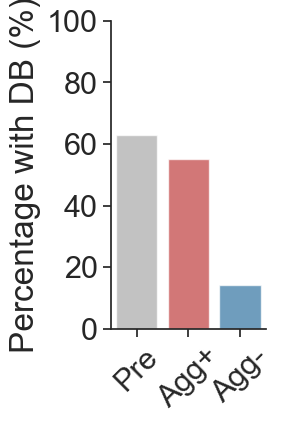

In [38]:
plt.subplots(figsize = (2,4))
sns.barplot(x = 'Behaviour_6hFD', y = 'yes',data = ad_prop, palette= ['darkgray', 'Tab:red', 'Tab:blue'], alpha = 0.7)
plt.xticks(rotation = 45)
plt.ylim([0,100])
plt.ylabel('Percentage with DB (%)')
plt.xlabel('')
sns.despine()
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

In [77]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## calcium T prop

cat_categ        no  no   yes  yes   All
Behaviour_6hFD                          
Agg+             23    0   14     0   37
Agg-              9    1   11     1   22
Pre              51    0   31     0   82
ZD7288            6    0    3     0    9
ZD7288_20         2    0    1     0    3
agrp_100         13    0    2     0   15
npy1r_antag       9    0    6     0   15
npy2r_antag       8    0    2     0   10
npy_10            7    1    2     0   10
npy_100           6    0    5     0   11
npy_antag        14    0    1     0   15
npykd            14    0    5     0   19
All             162    2   83     1  248
0.14200523883557525


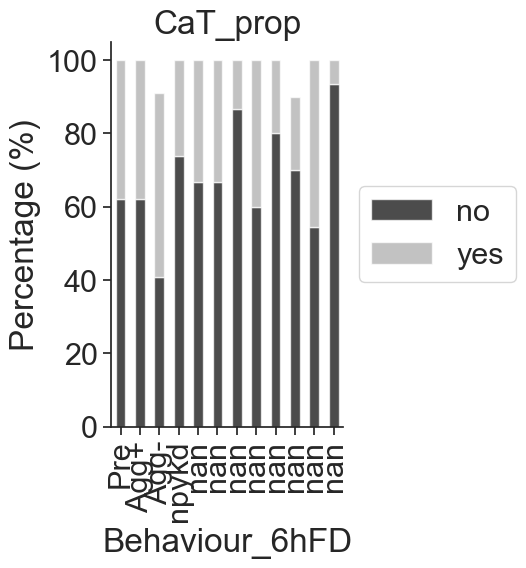

In [101]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

In [79]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## IH prop

IH              no  yes  All
Behaviour_6hFD              
Agg+            14   23   37
Agg-             1   21   22
Pre             24   58   82
ZD7288           9    0    9
ZD7288_20        3    0    3
agrp_100         6    9   15
npy1r_antag      4   11   15
npy2r_antag      2    8   10
npy_10           5    5   10
npy_100          6    5   11
npy_100_paired   2    1    3
npy_10_paired    0    5    5
npy_antag        3   12   15
npykd            1   18   19
All             80  176  256
1.8791922521382654e-06


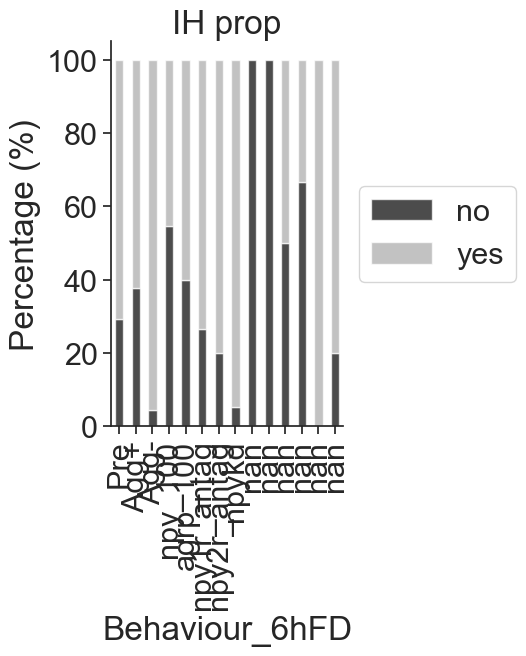

In [142]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic                7   37   44
silent               41   54   95
tonic                32   85  117
All                  80  176  256
0.002582480280337429


Text(0.5, 0, '')

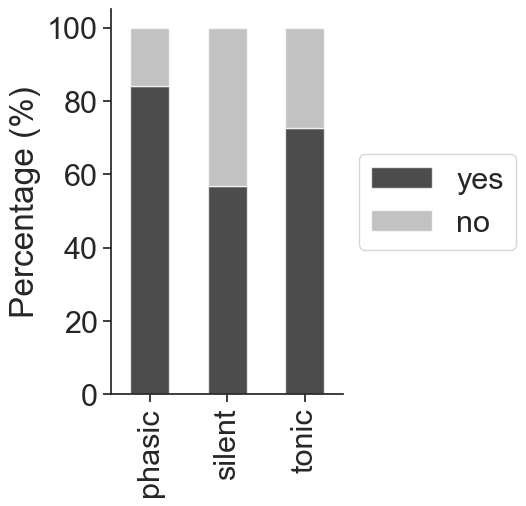

In [143]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# ramp analysis

In [318]:
from glob import glob
path = '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp'
states = ['Pre', 'Agg+', 'Agg-']
# list all directory in filepath
df_state = pd.DataFrame()

for state in states:
    files = [file for file in glob(f'{path}/{state}/*.xlsx')]
    df_files = []
    for file in files:
        try:
            df_file = pd.read_excel(file)
            df_file['filename'] = file
        except ValueError:
            print(file, state)
        df_files.append(df_file)

    df = pd.concat(df_files)
    df['state'] = state
    df_state = pd.concat([df_state, df])
    
        

/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp/Agg-/~$S1C4 09102023.xlsx Agg-
/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp/Agg-/~$S1C4 16102023.xlsx Agg-


In [281]:
df_state

,Event,I_Injected(pA),Event start,Event end,Ramp_start,Ramp_end,filename,state
0,1.0,25.0,0.000000,0.000000,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Pre
1,2.0,35.0,0.000000,0.000000,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Pre
2,3.0,45.0,0.000000,0.000000,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Pre
3,4.0,55.0,0.000000,0.000000,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Pre
4,5.0,65.0,0.000000,0.000000,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Pre
...,...,...,...,...,...,...,...,...
230,15.0,165.0,1948.599976,1960.599976,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Agg-
231,15.0,165.0,1976.300049,1992.900024,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Agg-
232,15.0,165.0,2003.900024,2019.400024,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Agg-
233,15.0,165.0,2028.300049,2045.800049,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Agg-


In [362]:
df_state.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
# df_state['Injected'] = pd.Categorical(df_state['Injected'], df_state['Injected'].unique()[:-2]).as_ordered()
df_state.sort_values('Injected', inplace = True)

df_state['state'] = pd.Categorical(df_state['state'], states).as_ordered()
# df_state.sort_values('Injected', inplace = True)


num_spike = df_state.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')

df_all = df_state.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

# df_state.loc[df['Event start '] == 0,'Event start '] = 2080
df_all['latency'] = df_all['Event start ']- df_all['Ramp_start']
df_all = df_all[df_all['latency'] > 0]
df_all['num_spike'] = num_spike.num_spike



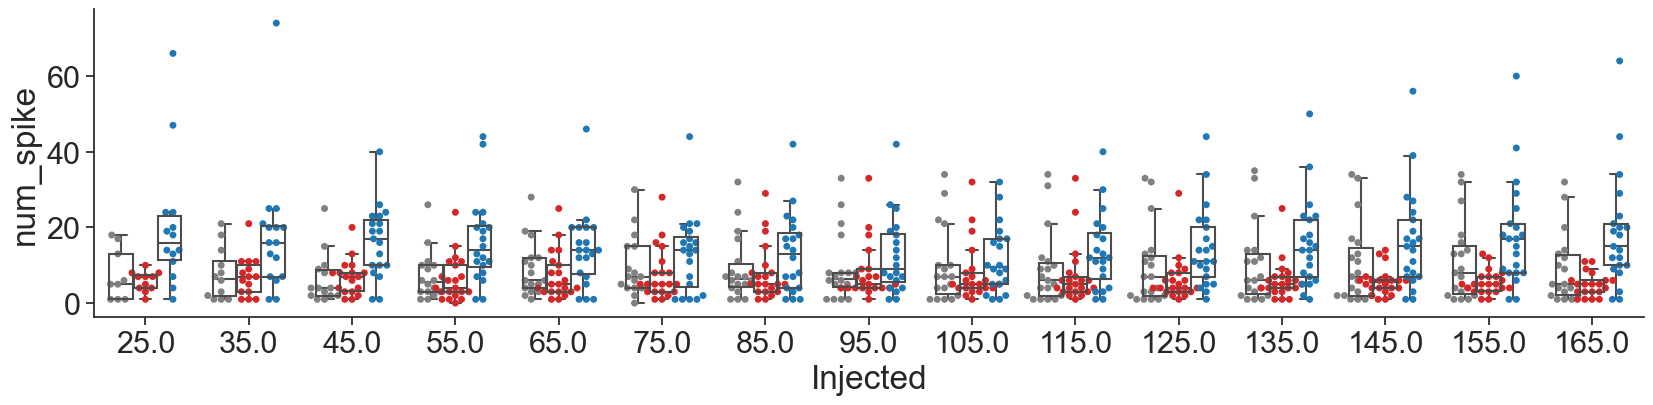

In [364]:
prop = 'num_spike'

fig, ax = plt.subplots(figsize = [20,4])

palette = ['gray', 'Tab:red', 'Tab:blue']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.swarmplot(x  = 'Injected', y = prop, hue = 'state',
               dodge = True, data = df_all, palette=palette, ax=ax)

sns.boxplot(x  = 'Injected', y = prop, hue = 'state',
                data = df_all, saturation=1, showfliers=False,
            width=0.7, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)

# turn off legend
leg = ax.get_legend()
if leg:
    leg.remove()

    sns.despine()



In [348]:
model = smf.ols('latency ~ C(Injected) * C(state)', data=df_all).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Injected),5.294804e+06,14.0,8.906274,2.277692e-18
C(state),1.168405e+06,2.0,13.757438,1.318575e-06
C(Injected):C(state),4.077394e+05,28.0,0.342925,9.994810e-01
Residual,3.600988e+07,848.0,NaN,NaN


# estrous cycle influence

I_zero             phasic  silent  tonic  All
estrous_stage                                
?                       1       1      2    4
D                       5       7     16   28
E                       2       3      3    8
M                       3       7     14   24
P                       6       6     12   24
VS to be stained        0       0      1    1
no VS                   1       2      9   12
not taken               1       2      1    4
All                    19      28     58  105
0.9417552913501139
I_zero         phasic  silent  tonic  All
estrous_stage                            
?                   0       1      0    1
D                   2       7      6   15
E                   3       1      0    4
M                   1       9      3   13
P                   1       3      2    6
All                 7      21     11   39
0.13218386353351907


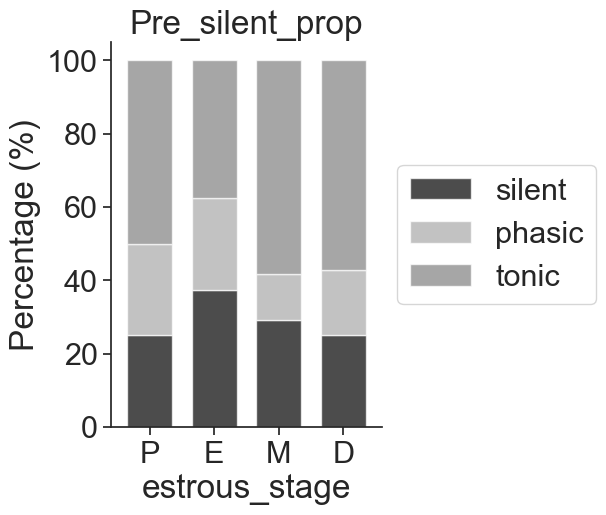

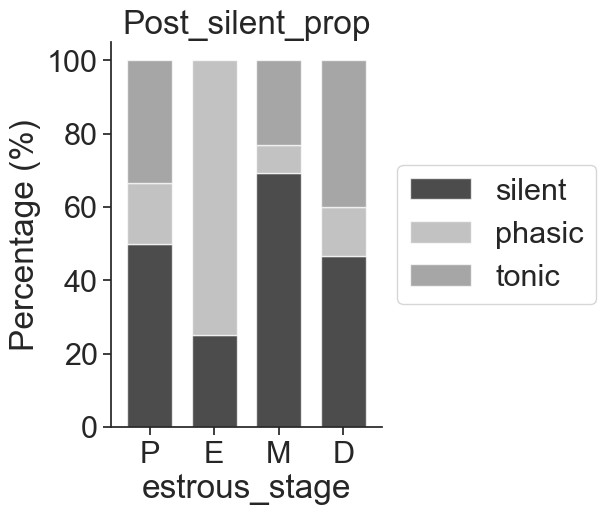

In [366]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

-0.5709724581245322 0.42902754187546777


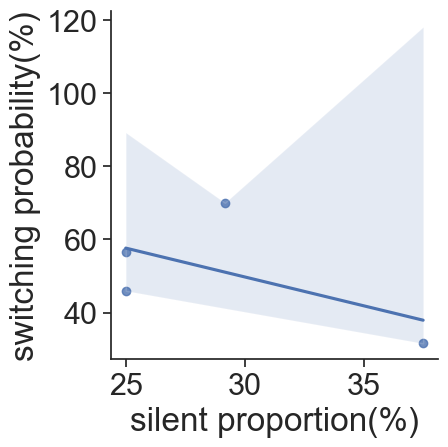

In [33]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

Ih_at_-120mV 0.009539512286860998


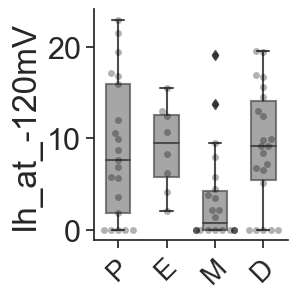

In [39]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

# ls = ['Ih_at_-120mV']

for state in ['Pre']:
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        state_df = state_df[state_df.Behaviour_6hFD == state]
        
        try:

            _, p = stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna())
            

            
            if p < 0.05:
                print(column , p)

                fig,ax = plt.subplots(figsize = (2.5,3))
                sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 0.3, color = 'black')
                sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5, palette = ['gray'])
                sns.despine()
                plt.xticks(rotation = 45, fontsize = 20)
                # plt.ylabel('Ih current (pA)', fontsize = 25)
                plt.xlabel('')
            
                # plt.title(f'{state}_{column}', pad = 20)
                plt.savefig(f'output_figures/{state}_{column}.png',dpi = 300, bbox_inches = 'tight')
            
            plt.show()
        except Exception:
            continue

cat_categ          no  yes  All
estrous_stage                  
?                   1    3    4
D                  11   11   22
E                   4    4    8
M                  17    5   22
P                  15    6   21
VS to be stained    1    0    1
not taken           2    2    4
All                51   31   82
0.23806780090893834
cat_categ estrous_stage         no        yes
4                     P  71.428571  28.571429
2                     E  50.000000  50.000000
3                     M  77.272727  22.727273
1                     D  50.000000  50.000000


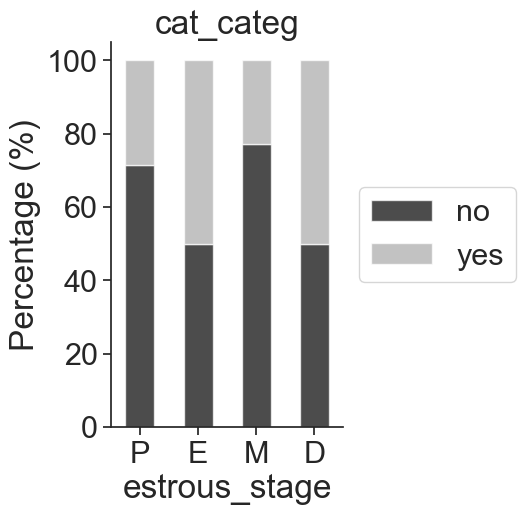

0.9146286513211039 0.08537134867889606


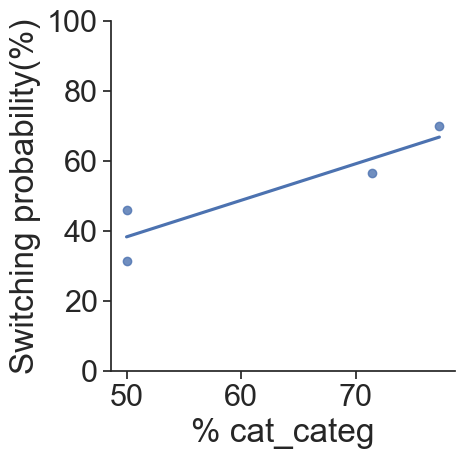

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   17   22
E                   0    8    8
M                  11   11   22
P                   5   16   21
VS to be stained    1    0    1
not taken           2    2    4
All                24   58   82
0.0352565677238345
IH estrous_stage         no         yes
4              P  23.809524   76.190476
2              E   0.000000  100.000000
3              M  50.000000   50.000000
1              D  22.727273   77.272727


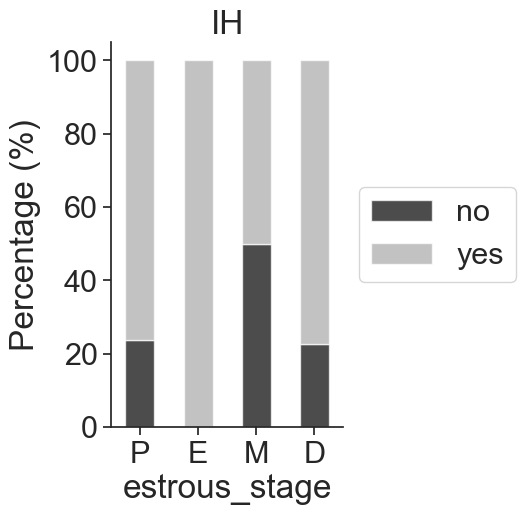

0.9665783850876507 0.033421614912349296


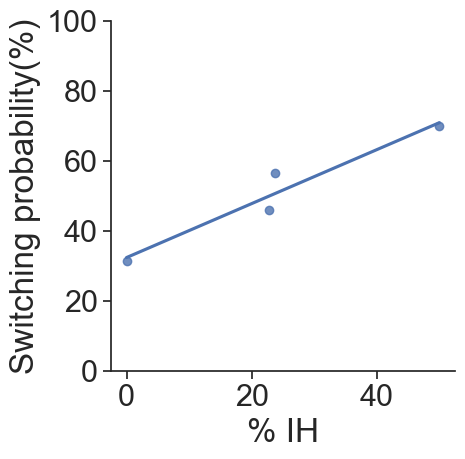

Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    6   10
E                  0   1    1    2
M                  0   7   11   18
P                  1   3    7   11
VS to be stained   0   0    1    1
All                1  15   27   43
0.9166519983189608
Adaptive estrous_stage         no        yes
4                    P  27.272727  63.636364
2                    E  50.000000  50.000000
3                    M  38.888889  61.111111
1                    D  40.000000  60.000000


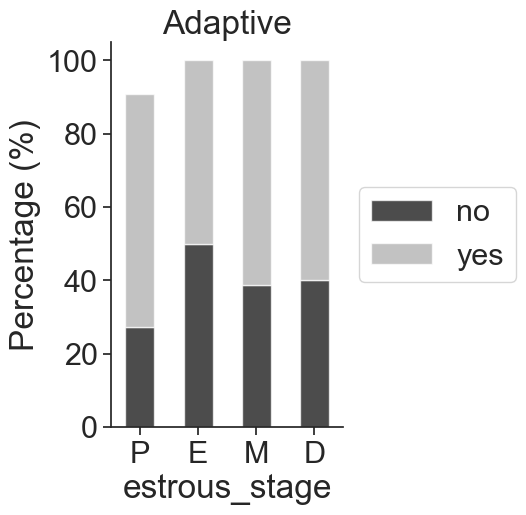

-0.6320737885969195 0.36792621140308046


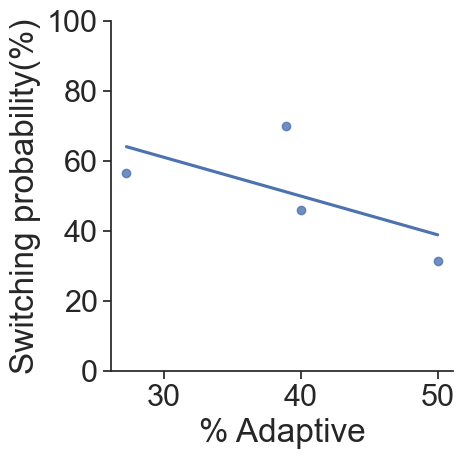

In [47]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr, ci = None)
    plt.ylim([0, 100])
    plt.xlabel(f'% {column}')
    plt.ylabel('Switching probability(%)')
    plt.savefig(f'output_figures/{column}_switching_corr.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   17   22
E                   0    8    8
M                  11   11   22
P                   5   16   21
VS to be stained    1    0    1
not taken           2    2    4
All                24   58   82
0.0352565677238345
Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    6   10
E                  0   1    1    2
M                  0   7   11   18
P                  1   3    7   11
VS to be stained   0   0    1    1
All                1  15   27   43
0.9166519983189608
-0.284545136651464 0.715454863348536


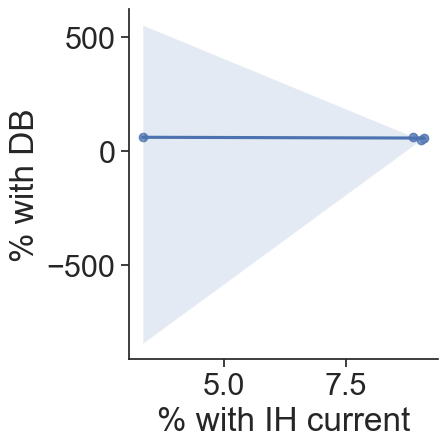

In [18]:

cols = ['no', 'yes']
estrous_stages = ['P', 'E', 'M', 'D']
ih_prop = proportion(ephys_pre, 'estrous_stage', 'IH', cols)
ih_est_mean = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
adaptive_prop = proportion(ephys_pre, 'estrous_stage', 'Adaptive', cols)
merged_df = pd.merge(ih_est_mean, adaptive_prop, on = 'estrous_stage')
merged_df = merged_df[merged_df.estrous_stage.isin(estrous_stages)]


r, p = sp.stats.pearsonr(merged_df['Ih_at_-120mV'], merged_df['yes'])
print(r, p)

sns.lmplot(x = 'Ih_at_-120mV', y = 'yes', data = merged_df)
# plt.ylim([0, /100])
plt.xlabel('% with IH current')
plt.ylabel('% with DB')
plt.show()